In [2]:
import  pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

In [3]:
df = pd.read_csv("insurance.csv")

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [5]:
df = df.drop(["sex", "smoker", "region"], axis=1)

In [6]:
df.corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


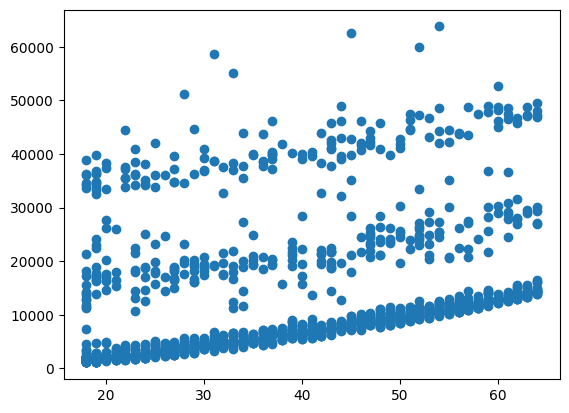

In [7]:
plt.scatter(df["age"],df["charges"])

* The feature and target column is wealky correalated so the data is non linear

In [8]:
X = df[["age","bmi","children"]]
y = df["charges"]

In [9]:
xtrain,xtest,ytrain,ytest = train_test_split(X,y,train_size=0.8,random_state=42)

In [10]:
xtrain

,age,bmi,children
560,46,19.950,2
1285,47,24.320,0
1142,52,24.860,0
969,39,34.320,5
486,54,21.470,3
...,...,...,...
1095,18,31.350,4
1130,39,23.870,5
1294,58,25.175,0
860,37,47.600,2


In [11]:
model = LinearRegression()

In [12]:
model.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
y_train_pred = model.predict(xtrain)
y_test_pred = model.predict(xtest)

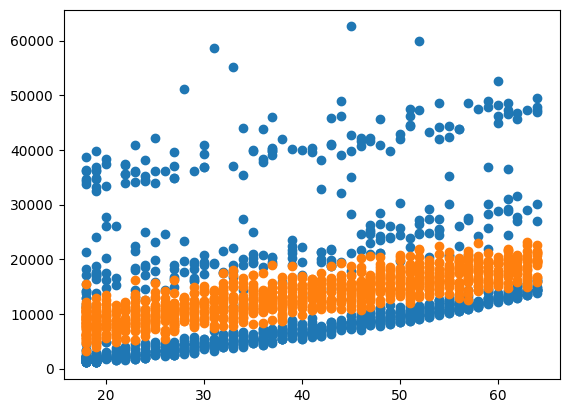

In [14]:
plt.scatter(xtrain.iloc[:,0],ytrain)
plt.scatter(xtrain.iloc[:,0],y_train_pred)

In [15]:
r2_train = r2_score(ytrain,y_train_pred)
r2_train

0.10987471044767094

In [16]:
r2_test = r2_score(ytest, y_test_pred)
r2_test

0.15489592484270753

* Both train and test data score are low so the model is underfit.
* We can overcome this by using polynomial regression.

In [17]:
poly = PolynomialFeatures(degree=4)
updated_xtrain = poly.fit_transform(xtrain)
updated_xtest = poly.transform(xtest) 

In [18]:
model.fit(updated_xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
y_pred_train = model.predict(updated_xtrain)

In [20]:
y_pred_test = model.predict(updated_xtest)

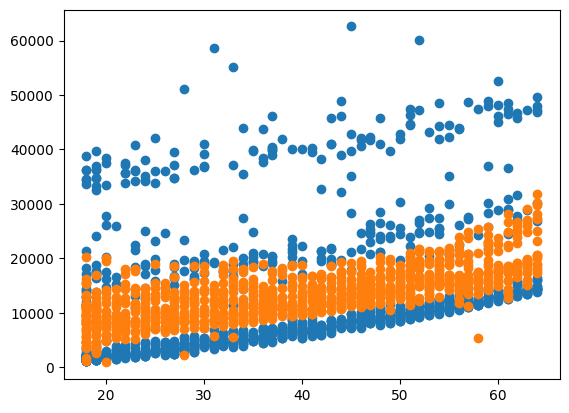

In [21]:
plt.scatter(updated_xtrain[:,1],ytrain)
plt.scatter(updated_xtrain[:,1], y_pred_train)

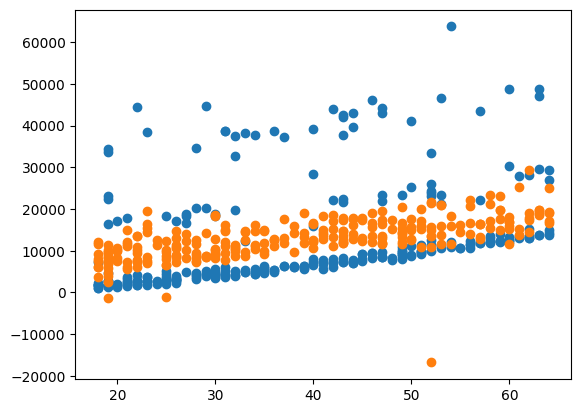

In [22]:
plt.scatter(updated_xtest[:,1],ytest)
plt.scatter(updated_xtest[:,1], y_pred_test)

In [23]:
r2_train_non = r2_score(ytrain,y_pred_train)
r2_train_non

0.144248511764398

In [24]:
r2_test_non = r2_score(ytest, y_pred_test)
r2_test_non

0.0814097231648111

degree 2
0.11972226371310857, 0.14407717923108032

degree 3
0.1334487519030486, 0.1204570540913934

degree 4
0.144248511764398, 0.0814097231648111

* The model is underfit